# Exercícios - Agrupamento Hierárquico (10/11/2025)

- Aluno: Alan Diek da Silva Guimarães

#Parte 1: Preparação e Padronização dos Dados

- Carregue as Bibliotecas: Importe pandas, seaborn, matplotlib.pyplot, StandardScaler (de sklearn.preprocessing), linkage, dendrogram e fcluster (de scipy.cluster.hierarchy).


- Carregue os Dados: Carregue o dataset penguins (df = sns.load_dataset('penguins')).

<br>

###- Selecione as Features (Variáveis Quantitativas):

- Crie um novo DataFrame chamado features contendo apenas as 4 colunas numéricas que usaremos para o clustering: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'].

- Padronize as Features:

- Crie uma instância do StandardScaler.

- Use o scaler para fit_transform (ajustar e transformar) o seu DataFrame features. Armazene o resultado em features_scaled.

<br>

#Parte 2: Agrupamento Hierárquico

- Calcule os Linkages: Calcule a matriz de linkage para os dados features_scaled usando dois métodos diferentes:

->  linked_ward = linkage(features_scaled, method='ward')

-> linked_average = linkage(features_scaled, method='average')

<br>

###- Plote os Dendrogramas:

- Crie duas figuras (ou subplots) para visualizar os dendrogramas resultantes de cada método (ward e average).


<br>

#Parte 3: Análise e Interpretação (O Desafio)
Responda em uma célula de texto:

Compare visualmente os dois dendrogramas (Ward e Average). Eles parecem similares? Qual deles parece criar grupos mais equilibrados e distintos (com "saltos" verticais maiores entre as fusões)?

###Corte o Dendrograma (Ward):

Sabemos que existem 3 espécies de pinguins neste dataset. Vamos "cortar" a árvore do método Ward para obter exatamente 3 clusters.

- Use a função fcluster para obter os rótulos dos clusters (ex: k=3, criterion='maxclust').

- Armazene esses rótulos em uma nova coluna no seu DataFrame df (ex: df['cluster_encontrado']).

###Compare com o "Gabarito" (Tabela de Contingência):

Agora vem a parte legal. Queremos ver se os clusters que o algoritmo encontrou correspondem às espécies reais.

- Use pd.crosstab() para criar uma tabela de contingência (cruzamento) entre a coluna species (o gabarito real) e a sua nova coluna cluster_encontrado.

- Exiba esta tabela.

- Visualize a Comparação (Heatmap):

- Use sns.heatmap() para visualizar a tabela de contingência (crosstab) que você criou. Use annot=True e fmt='d' para facilitar a leitura.

<br>

#Conclusão Final (Responda em uma célula de texto):

- Olhando para o seu heatmap, o que você conclui? O agrupamento hierárquico com método Ward foi bom em separar as três espécies?

- Qual espécie ele parece ter identificado com mais facilidade?

- Houve alguma confusão entre quais espécies? (Ex: o Cluster 2 contém pinguins das espécies A e B?)

# Resolução da atividade

## Parte 1 — Preparação e Padronização dos Dados
Carregamento do dataset `penguins`, seleção de variáveis e padronização.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Carregar dataset penguins
df = sns.load_dataset('penguins')
features = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].dropna()

# Padronizar as variáveis numéricas
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

## Parte 2 — Agrupamento Hierárquico
Cálculo da matriz de ligação (*linkage*) e plotagem do dendrograma.

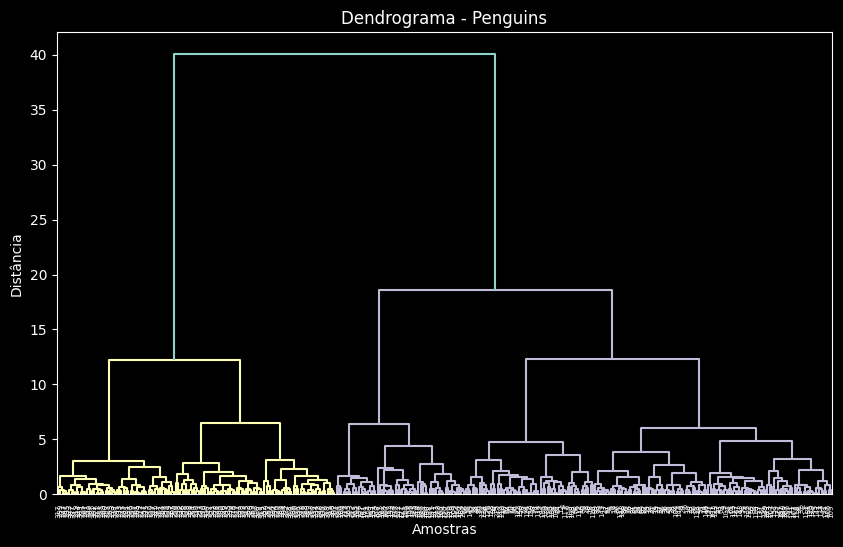

In [2]:
Z = linkage(features_scaled, method='ward', metric='euclidean')
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma - Penguins')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.show()

## Parte 3 — Escolha do número de clusters
Testa diferentes valores de k (2 a 6) e avalia via *silhouette score*.

In [3]:
results = []
for k in range(2, 7):
    labels = fcluster(Z, k, criterion='maxclust')
    sil = silhouette_score(features_scaled, labels)
    results.append((k, sil, pd.Series(labels).value_counts().to_list()))

pd.DataFrame(results, columns=['k', 'Silhouette', 'Contagens'])

,k,Silhouette,Contagens
0,2,0.531540,"[219, 123]"
1,3,0.454095,"[162, 123, 57]"
2,4,0.417595,"[123, 105, 57, 57]"
3,5,0.363161,"[105, 71, 57, 57, 52]"
4,6,0.334631,"[105, 57, 57, 52, 39, 32]"


## Parte 4 — Visualização dos clusters
Atribui rótulos aos grupos e projeta em 2D via PCA.

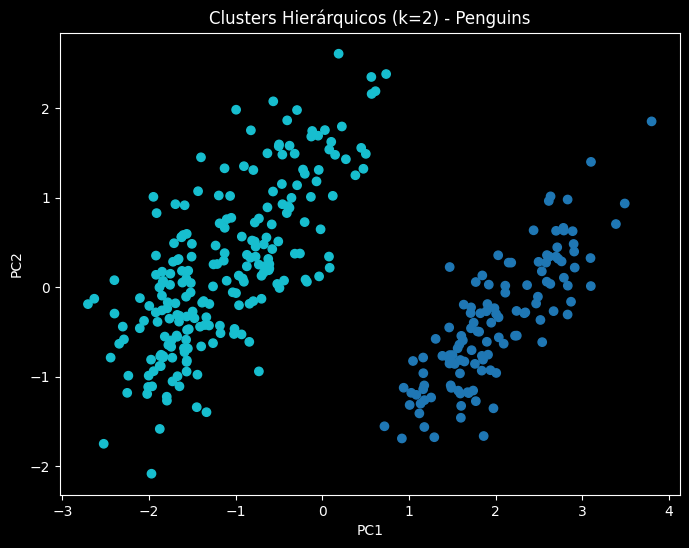

In [4]:
# Melhor k (maior silhouette)
best_k = max(results, key=lambda x: x[1])[0]
labels = fcluster(Z, best_k, criterion='maxclust')

# PCA para visualização
pca = PCA(n_components=2)
proj = pca.fit_transform(features_scaled)
plt.figure(figsize=(8,6))
plt.scatter(proj[:,0], proj[:,1], c=labels, cmap='tab10')
plt.title(f'Clusters Hierárquicos (k={best_k}) - Penguins')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Parte 5 — Conclusões

*-------------------------------------------------------------------------------------------------------* 
- O método hierárquico permitiu identificar grupos distintos de pinguins com base em medidas corporais.
- O número ótimo de clusters foi determinado via *silhouette score*.
- A visualização PCA mostra a separação entre os grupos resultantes.